In [1]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
from scipy.io import savemat,loadmat,whosmat
import numpy.ma as ma
from matplotlib.gridspec import GridSpec
from scipy import stats
import xarray as xr
plt.rcParams.update({'font.size': 12})

In [2]:
mydir = '../processed_netcdf/'
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
nm = 12
alph = ['(a)','(b)','(c)','(d)']
myhemi = ['SH','NH']
smallhemi=['sh','nh']
gencolours = ['blue','red','green','black']

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/xarray/core/nanops.py:140: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis=axis, dtype=dtype)


(12,)
Jan 0.6389366456824757
Feb 0.591768326133483
Mar 0.8227920227126164
Apr 1.2427071613993634
May 1.3529213374861984
Jun 1.3159501421888677
Jul 1.2150981181778793
Aug 0.8507147365895236
Sep 0.5627929762778408
Oct 0.612853601977136
Nov 0.6496981693257844
Dec 0.3624910377988346
(12,)


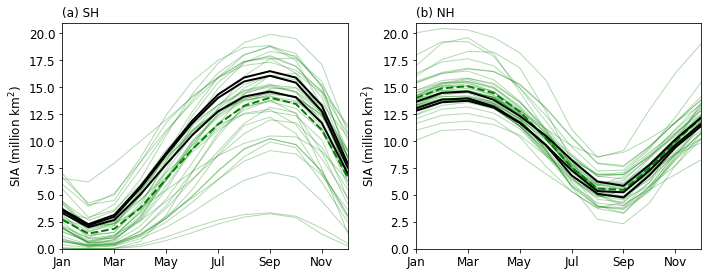

In [3]:
#mean over years (nanmean)
plt.rcParams.update({'font.size': 12})
model_ds = xr.open_dataset(mydir+'processed_CMIP6_sia_historical_r1_updated.nc').sel(year=slice('1979','2014')).mean(dim='year')
obs_ds =  xr.open_dataset(mydir+'processed_OBS_sia_1979-2018.nc').sel(year=slice('1979','2014'))

fig = plt.figure(figsize=(10,4))
for h, hemi in enumerate(myhemi):   
    ax = plt.subplot(1,2,h+1)
    ax.set_xticks(np.arange(nm)[::2])
    ax.set_xticklabels(months[::2])
    ax.set_ylabel(r'SIA (million km$^2$)')
    ax.set_title(alph[h]+' '+hemi,loc='left',fontsize=12)
    ax.set_ylim([0.,21.])
    ax.set_xlim([0,nm-1])
    
    for model in model_ds.name.values:
        ax.plot(np.arange(nm),model_ds['sia_'+smallhemi[h]].sel(name=model),c='green',linewidth=1,alpha=.3)   
    ax.plot(np.arange(nm),model_ds['sia_'+smallhemi[h]].mean(dim='name'),c='green',linewidth=2,linestyle='--')
    
    for ob in obs_ds.name.values:
        mean = obs_ds['sia_'+smallhemi[h]].sel(name=ob).mean(dim='year')
        ax.plot(np.arange(nm),mean,c='black',linewidth=2)
  
    mmm = model_ds['sia_'+smallhemi[h]].mean(dim='name')
    print(mmm.shape)
     
    if h == 0:
        lowestob = obs_ds['sia_'+smallhemi[h]].mean(dim='year').min(dim='name')
        for m in range(nm):
            print(months[m],(lowestob-mmm).values[m])
            
plt.tight_layout()
fig.savefig('fig1.pdf',bbox_inches='tight',dpi=300)
plt.show(); plt.close()

In [4]:
check = model_ds.sia_sh.sel(month=2)
check = check.where(check>10.,drop=True)
check

<xarray.DataArray 'sia_sh' (name: 0)>
array([], dtype=float64)
Coordinates:
  * name     (name) object 
    month    int64 2

In [5]:
for name in model_ds.name.values:
    print(name,model_ds.sia_nh.where(model_ds.name==name,drop=True).values[0],
         model_ds.sia_sh.where(model_ds.name==name,drop=True).values[0])

ACCESS-CM2_r1i1p1f1 [14.21123438 15.38624308 15.82555681 15.37418532 13.62456253 10.91260502
  7.83573119  5.51872502  5.62979828  7.66920094 10.19052336 12.24676863] [ 1.97861431  0.55962286  0.84865281  2.71378191  5.83644315  9.22439763
 11.67656308 13.2216275  13.67536259 13.03729497 10.91926551  6.69576777]
ACCESS-ESM1-5_r1i1p1f1 [12.45973039 13.66207872 13.96179467 13.45945364 11.919372    9.6048527
  7.1232812   5.13441345  4.65545131  5.84543873  7.73101379 10.21733064] [ 3.69091094  2.19602818  2.28368649  3.68907144  6.31718602  9.79737564
 12.38674535 13.83966321 14.21571745 13.39017081 11.10584919  7.19813931]
AWI-CM-1-1-MR_r1i1p1f1 [13.24565978 14.44880327 14.7231933  14.04074232 12.21748193  9.15708693
  5.82720525  3.93683465  3.64095088  5.31236911  8.25872057 10.92540513] [ 2.86336142  1.28649137  1.50495872  3.93577137  8.14620399 12.33612484
 15.46388298 17.3093485  17.94924328 16.98885457 14.05963318  8.35905429]
BCC-CSM2-MR_r1i1p1f1 [15.43625598 16.30300466 16.5109

In [6]:
print(model_ds.sia_nh.argmin(dim='month').values) # 1 in Oct, 7 in Aug
print(model_ds.sia_nh.argmax(dim='month').values) # 1 in Apr, 2 in Feb
print(model_ds.sia_sh.argmin(dim='month').values)
print(model_ds.sia_sh.argmax(dim='month').values)

[7 8 8 7 7 7 8 8 8 8 8 8 7 8 7 7 8 8 7 7 8 8 7 7 7 8 8 8 7 8 8 8 8 8 8 7 8
 7 8 7]
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 1 2 2]
[1 1 1 1 1 1 1 1 1 2 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1]
[8 8 8 8 8 8 8 8 8 9 9 9 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
 8 8 8]


SH
NH


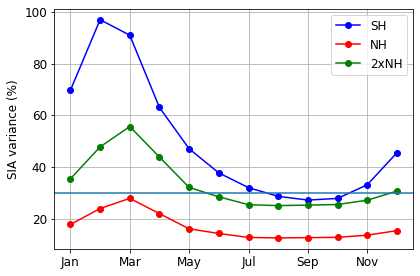

In [7]:
fig, ax = plt.subplots(1)   
ax.set_xticks(np.arange(nm)[::2])
ax.set_xticklabels(months[::2])
ax.set_ylabel(r'SIA variance (%)')
for h, hemi in enumerate(myhemi):    
  
    print(hemi)
    mydata = (100.*model_ds['sia_'+smallhemi[h]].std(dim='name')/model_ds['sia_'+smallhemi[h]].mean(dim='name')).values
    if h ==0:
        ax.plot(np.arange(nm), mydata ,label=hemi,c=gencolours[h],marker='o')
        
    elif h==1:
        ax.plot(np.arange(nm),np.append(mydata[6:],mydata[:6]) , label=hemi,c=gencolours[h],marker='o')
        ax.plot(np.arange(nm), 2.*np.append(mydata[6:],mydata[:6]), label='2x'+hemi,c='green',marker='o')
        
    
ax.axhline(y=30)
plt.grid()    
plt.legend()
plt.tight_layout()
plt.show(); plt.close()